---
title: Network, timeseries & surface combined
description: "Advanced multi-panel figure combining a brain network, a time-series plot, and a cortical surface map in one layout."
categories: [advanced, networks, timeseries, surface]
jupyter: python3
---

In [ ]:
from nibabel.freesurfer.io import read_annot
import matplotlib.pyplot as plt
from bsplot import data, style
from bsplot.data.surface import get_surface_geometry
from bsplot.graph import create_network, get_centers_from_surface_parc

# Load surface geometry and parcellation
vertices_lh, faces_lh = get_surface_geometry(template="fsaverage", hemi="lh", density="164k")
vertices_rh, faces_rh = get_surface_geometry(template="fsaverage", hemi="rh", density="164k")

labels_lh, colors_lh, names_lh = read_annot("/Applications/freesurfer/7.4.1/subjects/fsaverage/label/lh.aparc.annot")
labels_rh, colors_rh, names_rh = read_annot("/Applications/freesurfer/7.4.1/subjects/fsaverage/label/rh.aparc.annot")
centers_lh = get_centers_from_surface_parc(vertices_lh, labels_lh)
centers_rh = get_centers_from_surface_parc(vertices_rh, labels_rh)

centers_all = {**centers_lh, **centers_rh}

In [ ]:
import numpy as np
sc = np.load("/Users/leonmartin_bih/work_data/toolboxes/tvboptim/src/tvboptim/data/connectivity/dk_average/data.npz")

In [ ]:
# === TVB abbreviated labels → FreeSurfer aparc names ===
sc_abbrev_to_aparc = {
    "BSTS": "bankssts", "CACG": "caudalanteriorcingulate", "CMFG": "caudalmiddlefrontal",
    "CU": "cuneus", "EC": "entorhinal", "FG": "fusiform", "IPG": "inferiorparietal",
    "ITG": "inferiortemporal", "ICG": "isthmuscingulate", "LOG": "lateraloccipital",
    "LOFG": "lateralorbitofrontal", "LG": "lingual", "MOFG": "medialorbitofrontal",
    "MTG": "middletemporal", "PHIG": "parahippocampal", "PaCG": "paracentral",
    "POP": "parsopercularis", "POR": "parsorbitalis", "PTR": "parstriangularis",
    "PCAL": "pericalcarine", "PoCG": "postcentral", "PCG": "posteriorcingulate",
    "PrCG": "precentral", "PCU": "precuneus", "RACG": "rostralanteriorcingulate",
    "RMFG": "rostralmiddlefrontal", "SFG": "superiorfrontal", "SPG": "superiorparietal",
    "STG": "superiortemporal", "SMG": "supramarginal", "FP": "frontalpole",
    "TP": "temporalpole", "TTG": "transversetemporal", "IN": "insula",
}
subcortical_abbrevs = {"CER", "TH", "CA", "PU", "PA", "HI", "AM", "AC"}

# Build aparc name → label index lookup
name_to_idx = {
    (n.decode() if isinstance(n, bytes) else str(n)): idx
    for idx, n in enumerate(names_lh)
}

# Parse SC labels, get cortical entries with their aparc label index
parsed = [str(l).split(".") for l in sc["region_labels"]]
cortical_entries = [
    (i, hemi, sc_abbrev_to_aparc[abbrev], name_to_idx[sc_abbrev_to_aparc[abbrev]])
    for i, (hemi, abbrev) in enumerate(parsed)
    if abbrev not in subcortical_abbrevs
]

# Sort: LH first (by aparc label index), then RH (by aparc label index)
cortical_entries.sort(key=lambda x: (x[1] != "L", x[3]))
reorder_idx = np.array([e[0] for e in cortical_entries])

# Extract reordered cortical-only SC submatrix
sc_cortical = sc["weights"][np.ix_(reorder_idx, reorder_idx)]

# Build centers keyed by sequential index 0..67 (matching sc_cortical rows/cols)
# Labels are also 0..67 so create_network can find centers[label] correctly
centers_src = {"L": centers_lh, "R": centers_rh}
centers_matched = {
    i: centers_src[hemi][aparc_idx]
    for i, (_, hemi, _, aparc_idx) in enumerate(cortical_entries)
}
labels_matched = list(range(len(cortical_entries)))  # 0..67, same as centers keys

print(f"Cortical SC: {sc_cortical.shape}, centers: {len(centers_matched)}, labels: {len(labels_matched)}")
n_lh = sum(1 for e in cortical_entries if e[1] == "L")
print(f"LH: {n_lh} (indices 0..{n_lh-1}), RH: {len(cortical_entries)-n_lh} (indices {n_lh}..{len(cortical_entries)-1})")

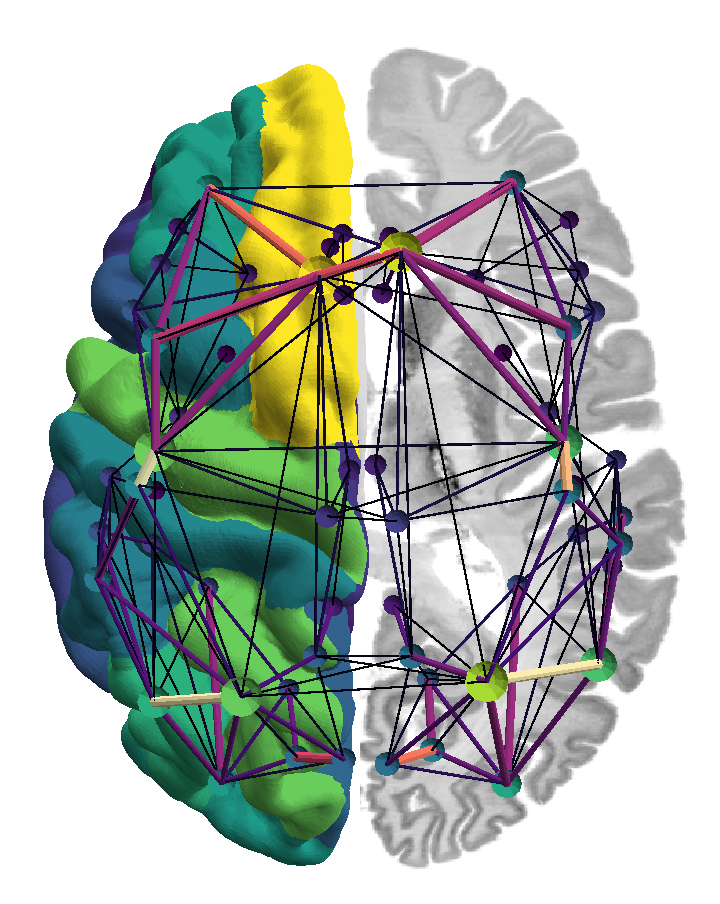

In [12]:
from importlib import reload
import bsplot.surface
from bsplot.graph import create_edge_mesh, create_node_mesh

reload(bsplot.surface)

G = create_network(
    centers_matched,
    sc_cortical,
    labels=labels_matched,
    threshold_percentile=92,
    directed=False,
)

for node in G.nodes():
    G.nodes[node]["strength"] = sum(d["weight"] for _, _, d in G.edges(node, data=True))

# only connected nodes (same behavior as plot_network_on_surface)
connected_nodes = [n for n in G.nodes() if G.degree(n) > 0]

node_to_aparc = {
    i: (hemi, aparc_idx) for i, (_, hemi, _, aparc_idx) in enumerate(cortical_entries)
}

overlay_lh = np.full(len(vertices_lh), np.nan)
overlay_rh = np.full(len(vertices_rh), np.nan)

for node_id in connected_nodes:
    hemi, aparc_idx = node_to_aparc[node_id]
    strength = G.nodes[node_id]["strength"]
    if hemi == "L":
        overlay_lh[labels_lh == aparc_idx] = strength
    else:
        overlay_rh[labels_rh == aparc_idx] = strength

fig, ax = plt.subplots(layout="compressed", figsize=(3, 3))

view = "top"
node_mesh, node_overlay = create_node_mesh(
    G,
    radius=2,
    nodes=connected_nodes,
    data_key="strength",
    scale={"strength": 2, "mode": "exp"},
)
edge_mesh, edge_overlay = create_edge_mesh(
    G,
    radius=0.1,
    data_key="weight",
    scale={"weight": 10, "mode": "exp"},
)

# 1) surface only
bsplot.surface.plot_surf(
    "fsaverage",
    ax=ax,
    surface_density="164k",
    hemi="lh",
    view=view,
    alpha=1,
    overlay=overlay_lh,
    cmap="viridis",
    threshold=99,
    parcellated=True,
)

# 2) combined edge + node meshes (single call)
bsplot.surface.plot_surf(
    [edge_mesh, node_mesh],
    ax=ax,
    hemi="lh",
    view=view,
    overlay=[edge_overlay, node_overlay],
    cmap=["magma", "viridis"],
)

bsplot.plot_slice(
    bsplot.templates.bigbrain,
    ax=ax,
    view="horizontal",
    slice_mm=10,
    cmap="grey",
    set_axis_extent=False,
    zorder=-1,
    hide_hemi="left",
)
bsplot.plot_slice(
    bsplot.templates.bigbrain,
    ax=ax,
    view="horizontal",
    slice_mm=10,
    cmap="grey",
    zorder=-1,
    alpha=0,
)

ax.axis("off")
style.format_fig(fig)
plt.show()

Node 60 (R.superiorfrontal), degree=16, strength=773061.1, color=crimson, y=25.6
Node 56 (R.precentral), degree=13, strength=598988.5, color=darkorange, y=-12.4
Node 61 (R.superiorparietal), degree=15, strength=728053.7, color=royalblue, y=-59.6
  Node 60 projected: (9.3, 28.5)
  Node 56 projected: (42.2, -12.4)
  Node 61 projected: (26.9, -64.0)


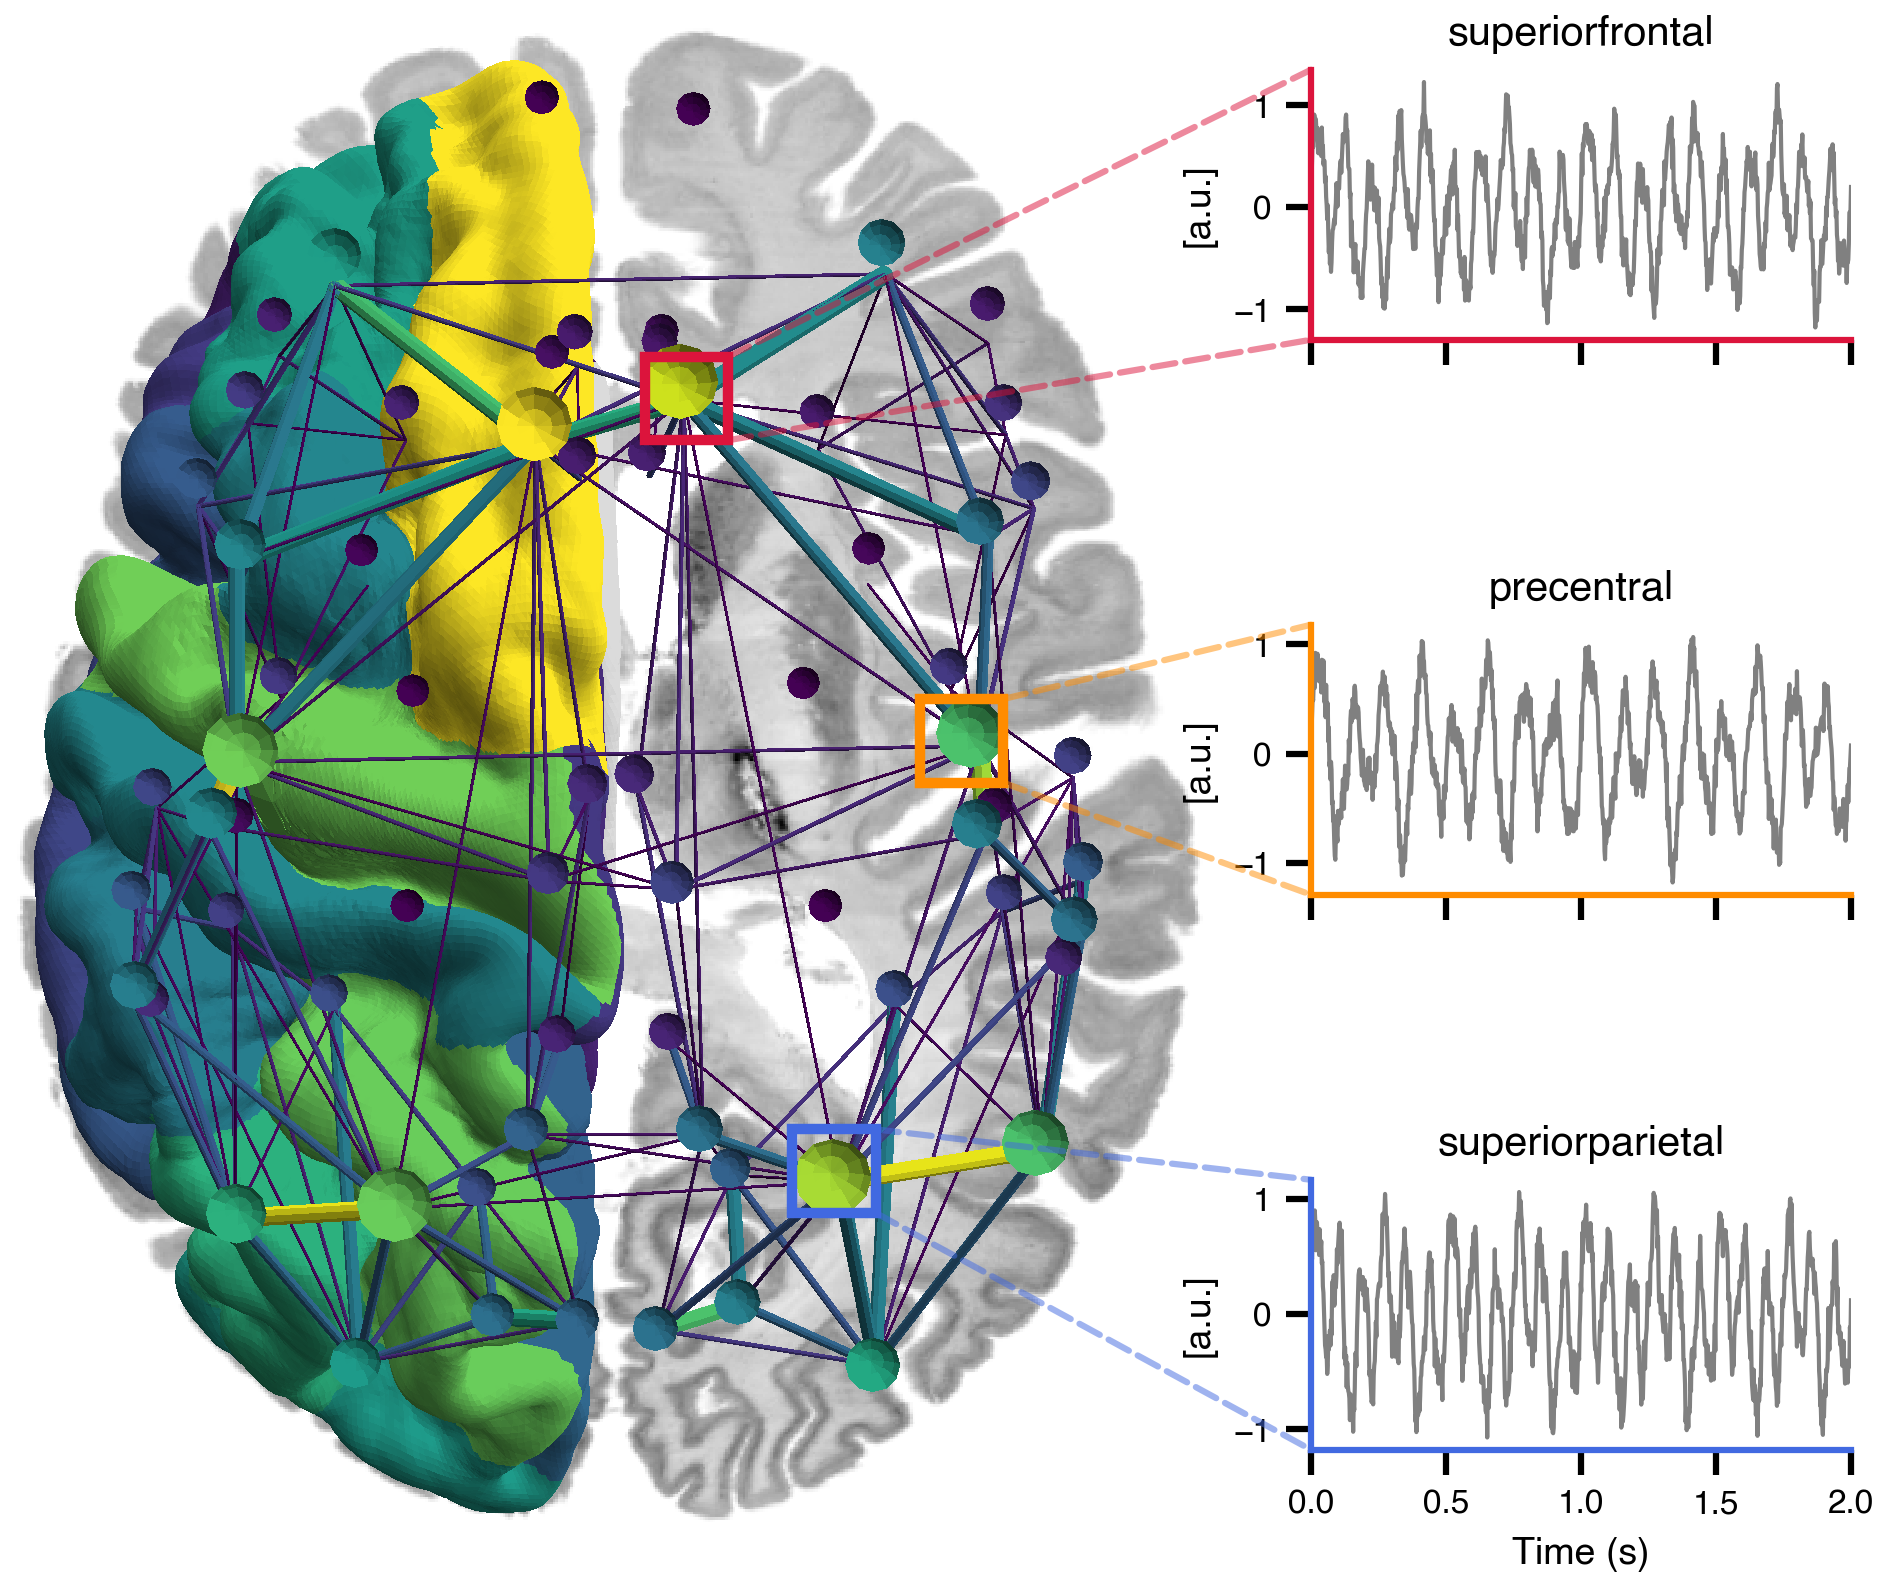

In [13]:
# from importlib import reload
# import bsplot.surface

# reload(bsplot.surface)

# from bsplot.surface import yrotate, zrotate, xrotate, perspective, translate
# from bsplot.data.surface import get_surface_geometry
# from bsplot.graph import create_edge_mesh, create_node_mesh
# from matplotlib.patches import ConnectionPatch

# # --- Pick 3 spatially spread RH nodes (top / middle / bottom) ---
# rh_nodes = [n for n in G.nodes() if node_to_aparc[n][0] == "R" and G.degree(n) > 0]
# # Sort by y-position (vertical axis in top view) descending -> top-to-bottom
# rh_by_y = sorted(rh_nodes, key=lambda n: G.nodes[n]["pos"][1], reverse=True)
# n_rh = len(rh_by_y)
# # Pick highest-degree node from top third, middle third, bottom third
# thirds = [
#     rh_by_y[: n_rh // 3],
#     rh_by_y[n_rh // 3 : 2 * n_rh // 3],
#     rh_by_y[2 * n_rh // 3 :],
# ]
# zoom_nodes = [max(tercile, key=lambda n: G.degree(n)) for tercile in thirds]
# zoom_colors = ["crimson", "darkorange", "royalblue"]
# zoom_seeds = [42, 7, 99]
# zoom_freqs = [(10, 3, 25), (8, 5, 20), (12, 4, 30)]  # alpha/theta/beta per node

# for zn, zc in zip(zoom_nodes, zoom_colors):
#     zname = cortical_entries[zn][2]
#     print(
#         f"Node {zn} (R.{zname}), degree={G.degree(zn)}, strength={G.nodes[zn]['strength']:.1f}, color={zc}, y={G.nodes[zn]['pos'][1]:.1f}"
#     )

# # --- Project nodes to 2D using the SAME pipeline as plot_surf ---
# verts, _ = get_surface_geometry(template="fsaverage", hemi="lh", density="164k")
# verts = verts.astype(np.float32)
# center = (verts.max(0) + verts.min(0)) / 2
# scale = max(verts.max(0) - verts.min(0))

# view_angle, xr, zr = 0.0, 0.0, 0.0

# MVP = (
#     perspective(25, 1, 1, 100)
#     @ translate(0, 0, -3)
#     @ yrotate(view_angle)
#     @ zrotate(zr)
#     @ xrotate(xr)
# )

# proj_verts = (verts - center) / scale
# V_all = np.c_[proj_verts, np.ones(len(proj_verts))] @ MVP.T
# V_all /= V_all[:, 3:4]
# pxmin, pxmax = V_all[:, 0].min(), V_all[:, 0].max()
# pymin, pymax = V_all[:, 1].min(), V_all[:, 1].max()

# ROT = yrotate(view_angle) @ zrotate(zr) @ xrotate(xr)
# V_world = np.c_[verts, np.ones(len(verts))] @ ROT.T
# wxmin, wxmax = V_world[:, 0].min(), V_world[:, 0].max()
# wymin, wymax = V_world[:, 1].min(), V_world[:, 1].max()
# sx = (wxmax - wxmin) / (pxmax - pxmin)
# sy = (wymax - wymin) / (pymax - pymin)

# # Project each node
# node_2d = {}
# for zn in zoom_nodes:
#     pos = np.array(G.nodes[zn]["pos"])
#     np_ = (pos - center) / scale
#     np4 = np.append(np_, 1) @ MVP.T
#     np4 /= np4[3]
#     nx = wxmin + (np4[0] - pxmin) * sx
#     ny = wymin + (np4[1] - pymin) * sy
#     node_2d[zn] = (nx, ny)
#     print(f"  Node {zn} projected: ({nx:.1f}, {ny:.1f})")

# # --- Main figure ---
# fig = plt.figure()
# ax = fig.add_axes([0.0, 0.0, 0.55, 1.0])

# node_mesh, node_overlay = create_node_mesh(
#     G,
#     radius=2,
#     data_key="strength",
#     scale={"strength": 2, "mode": "exp"},
# )
# edge_mesh, edge_overlay = create_edge_mesh(
#     G,
#     radius=0.1,
#     data_key="weight",
#     scale={"weight": 10, "mode": "exp"},
# )

# # 1) Surface
# bsplot.surface.plot_surf(
#     "fsaverage",
#     ax=ax,
#     surface_density="164k",
#     hemi="lh",
#     view="top",
#     alpha=1,
#     overlay=overlay_lh,
#     cmap="viridis",
#     threshold=0,
#     parcellated=True,
# )

# # 2) Edge mesh
# bsplot.surface.plot_surf(
#     edge_mesh,
#     ax=ax,
#     hemi="lh",
#     view="top",
#     alpha=1.0,
#     overlay=edge_overlay,
#     cmap="viridis",
# )

# # 3) Node mesh
# bsplot.surface.plot_surf(
#     node_mesh,
#     ax=ax,
#     hemi="lh",
#     view="top",
#     alpha=1.0,
#     overlay=node_overlay,
#     cmap="viridis",
# )
# ax.axis("off")

# # --- Three stacked insets on the right, spanning full image height ---
# inset_left = 0.6
# inset_width = 0.25
# inset_height = 0.18
# top_pad, bottom_pad = 0.03, 0.05
# gap = (1.0 - top_pad - bottom_pad - 3 * inset_height) / 2
# # Stack from top to bottom
# inset_bottoms = [
#     1.0 - top_pad - inset_height - i * (inset_height + gap) for i in range(3)
# ]

# zoom_r = 5
# t = np.linspace(0, 2, 1000)

# for idx, (zn, color, seed, freqs) in enumerate(
#     zip(zoom_nodes, zoom_colors, zoom_seeds, zoom_freqs)
# ):
#     zname = cortical_entries[zn][2]
#     nx, ny = node_2d[zn]

#     # Rectangle around node on brain
#     rect = plt.Rectangle(
#         (nx - zoom_r, ny - zoom_r),
#         2 * zoom_r,
#         2 * zoom_r,
#         linewidth=2.5,
#         edgecolor=color,
#         facecolor="none",
#         zorder=10,
#     )
#     ax.add_patch(rect)

#     # Timeseries inset
#     ax_ts = fig.add_axes([inset_left, inset_bottoms[idx], inset_width, inset_height])
#     ax_ts.set_facecolor("white")

#     np.random.seed(seed)
#     signal = (
#         0.6 * np.sin(2 * np.pi * freqs[0] * t)
#         + 0.3 * np.sin(2 * np.pi * freqs[1] * t + 0.5)
#         + 0.15 * np.sin(2 * np.pi * freqs[2] * t)
#         + 0.1 * np.random.randn(len(t))
#     )

#     ax_ts.plot(t, signal, color="grey", linewidth=1)
#     ax_ts.set_ylabel("[a.u.]")
#     ax_ts.set_title(f"{zname}")
#     ax_ts.tick_params()
#     ax_ts.spines["top"].set_visible(False)
#     ax_ts.spines["right"].set_visible(False)
#     ax_ts.spines["left"].set_color(color)
#     ax_ts.spines["bottom"].set_color(color)
#     ax_ts.set_xlim(0, 2)

#     # Only show x-label on bottom inset
#     if idx == 2:
#         ax_ts.set_xlabel("Time (s)")
#     else:
#         ax_ts.set_xticklabels([])

#     # Connection lines from rectangle corners to inset left edge
#     for (cx, cy), (ix, iy) in [
#         ((nx + zoom_r, ny + zoom_r), (0, 1)),
#         ((nx + zoom_r, ny - zoom_r), (0, 0)),
#     ]:
#         fig.add_artist(
#             ConnectionPatch(
#                 xyA=(cx, cy),
#                 coordsA=ax.transData,
#                 xyB=(ix, iy),
#                 coordsB=ax_ts.transAxes,
#                 color=color,
#                 linewidth=1.5,
#                 linestyle="--",
#                 alpha=0.5,
#             )
#         )

# bsplot.plot_slice(
#     bsplot.templates.bigbrain,
#     ax=ax,
#     view="horizontal",
#     slice_mm=10,
#     cmap="gray",
#     zorder=-1,
# )
# # style.format_fig(fig)
# plt.show()

Node 60 (R.superiorfrontal), degree=16, strength=773061.1, color=crimson, y=25.6
Node 56 (R.precentral), degree=13, strength=598988.5, color=darkorange, y=-12.4
Node 61 (R.superiorparietal), degree=15, strength=728053.7, color=royalblue, y=-59.6
  Node 60 projected: (9.3, 28.5)
  Node 56 projected: (42.2, -12.4)
  Node 61 projected: (26.9, -64.0)


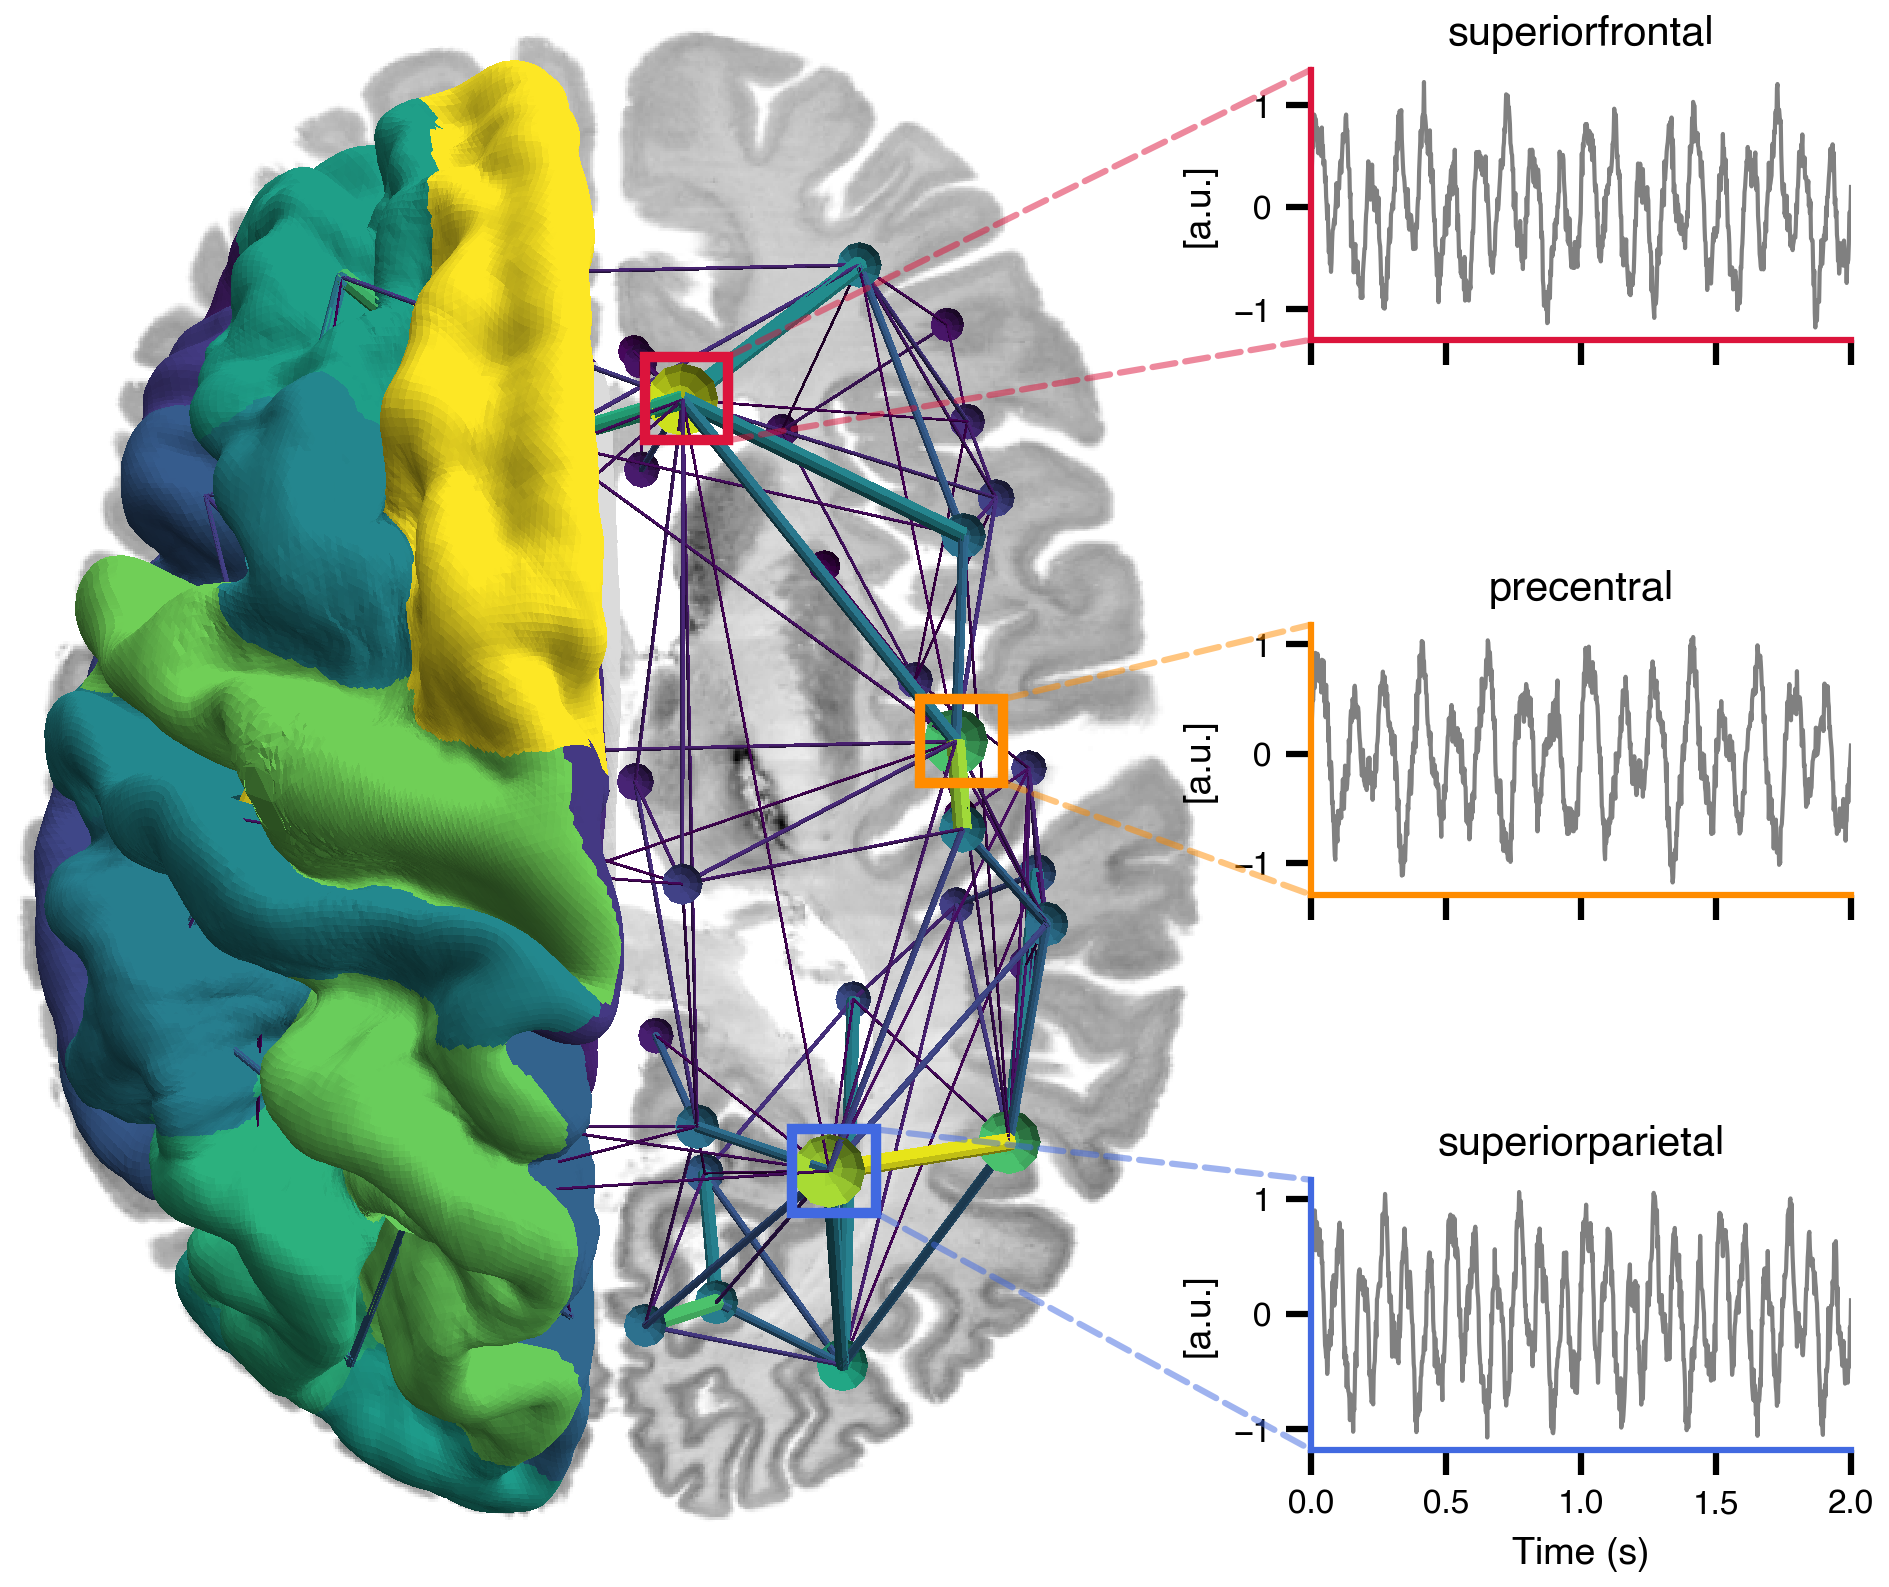